In [1]:
#import data manipulation libraries
import numpy as np
import pandas as pd

#import data visualziation libraries
import matplotlib.pyplot as plt
import seaborn as sns

#import logging
import logging
logging.basicConfig(filename='model.log',
                    level=logging.INFO,
                    filemode='w',
                      format='%(asctime)s:%(levelname)s:%(message)s',
                      force=True)

import warnings
warnings.filterwarnings('ignore')

In [2]:
#data import using pandas function
url="https://raw.githubusercontent.com/Frisk516/Restaurant_revenue_MLModel/refs/heads/main/Restaurant_revenue%20(1).csv"
df=pd.read_csv(url,sep=',')
#shuffle the dataset
df.sample(frac=1)

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
617,76,26.636295,14.997015,Japanese,14.022509,1,36,289.024685
210,28,42.903355,0.458656,Mexican,20.225564,0,8,164.637535
105,17,46.509979,9.720310,Mexican,23.142326,1,20,131.235042
186,46,23.807686,2.494281,Italian,26.088949,0,13,227.949084
337,62,23.454819,19.561236,Japanese,42.119252,1,85,245.661809
...,...,...,...,...,...,...,...,...
220,84,20.547352,7.469252,American,28.960251,1,91,267.630470
182,81,43.004293,15.125293,Japanese,41.722521,1,97,385.048827
763,84,33.859419,9.828364,Mexican,28.675124,1,48,312.761996
68,15,39.043823,0.760437,Mexican,22.352091,1,46,113.210789


In [3]:
logging.info("Data imported successfully")

In [4]:
#separating numerical and categorical data
numerical_data=df.select_dtypes(exclude=object)
categorial_data=df.select_dtypes(include=object)

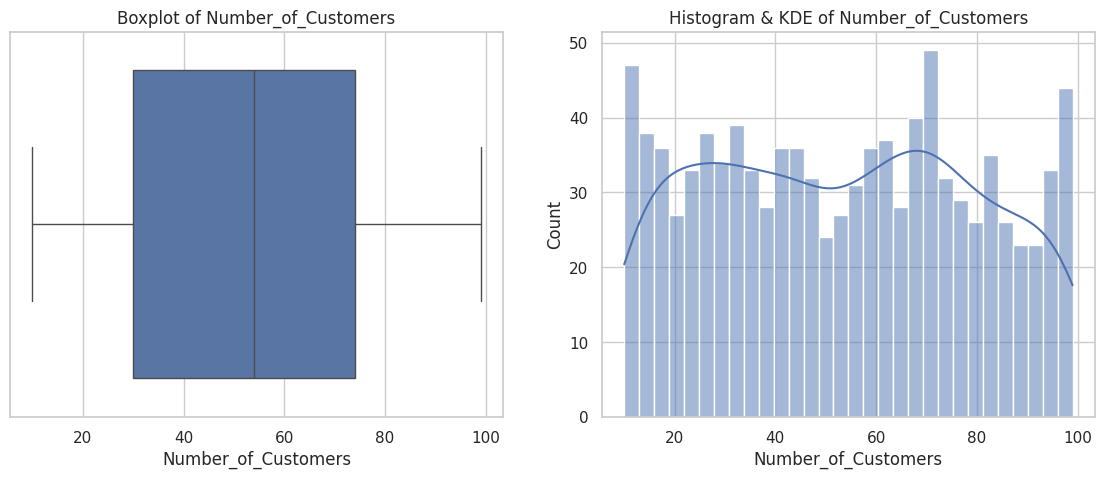

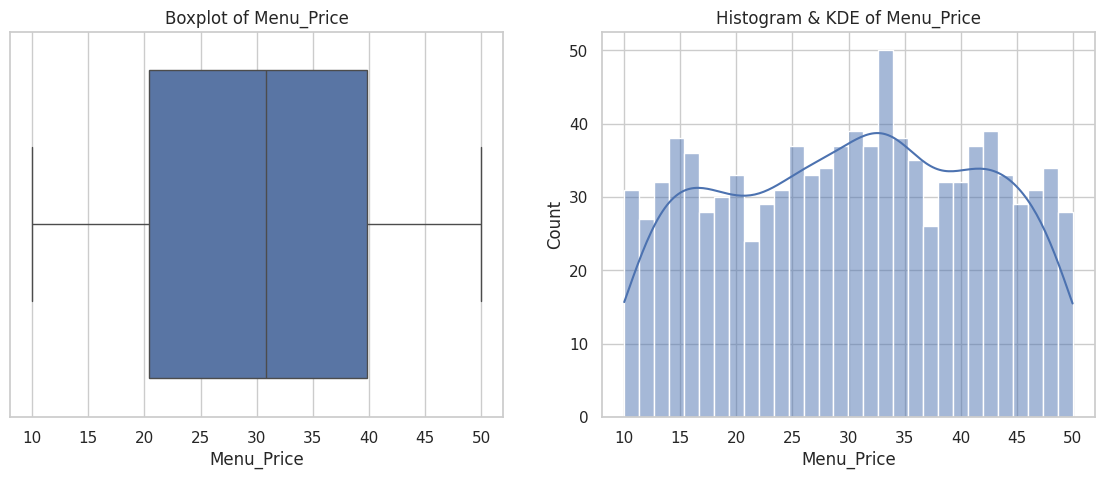

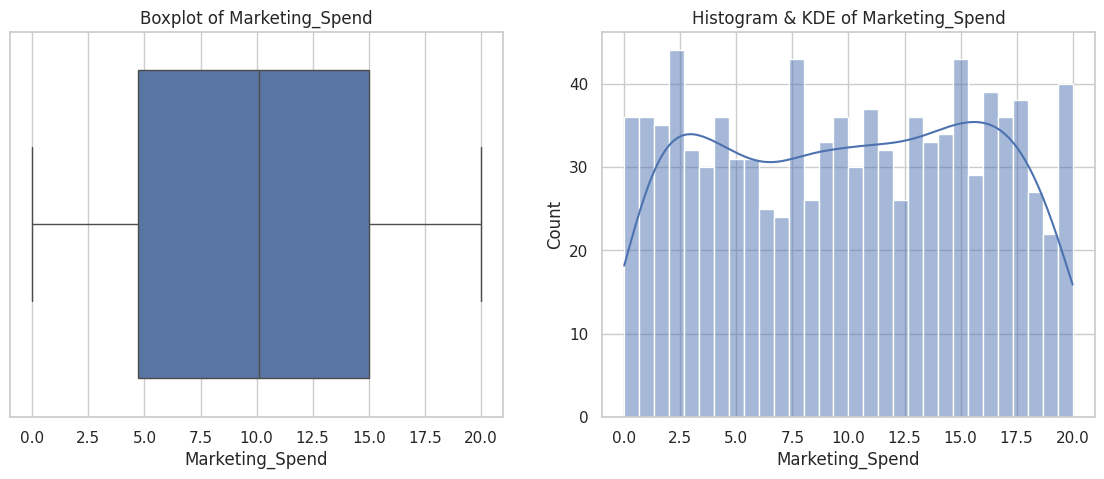

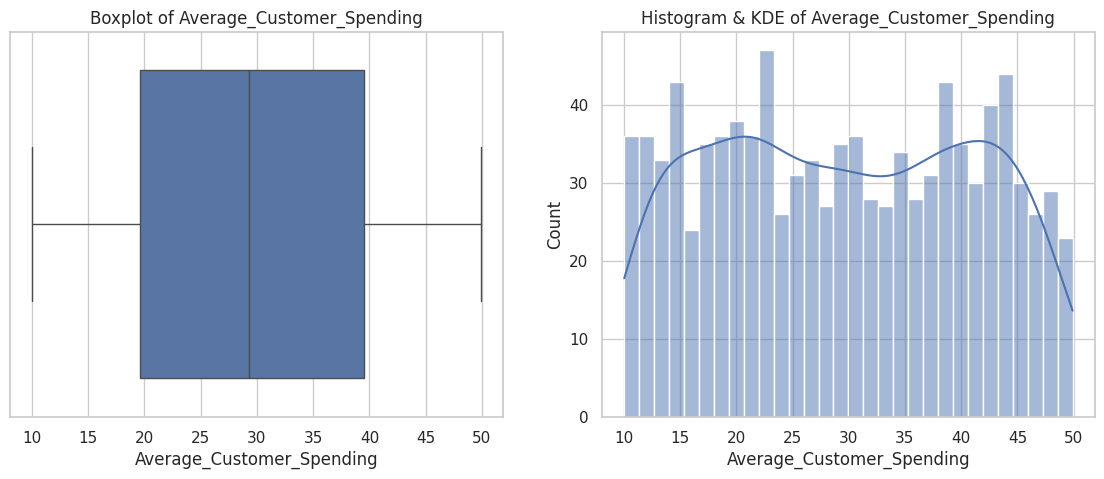

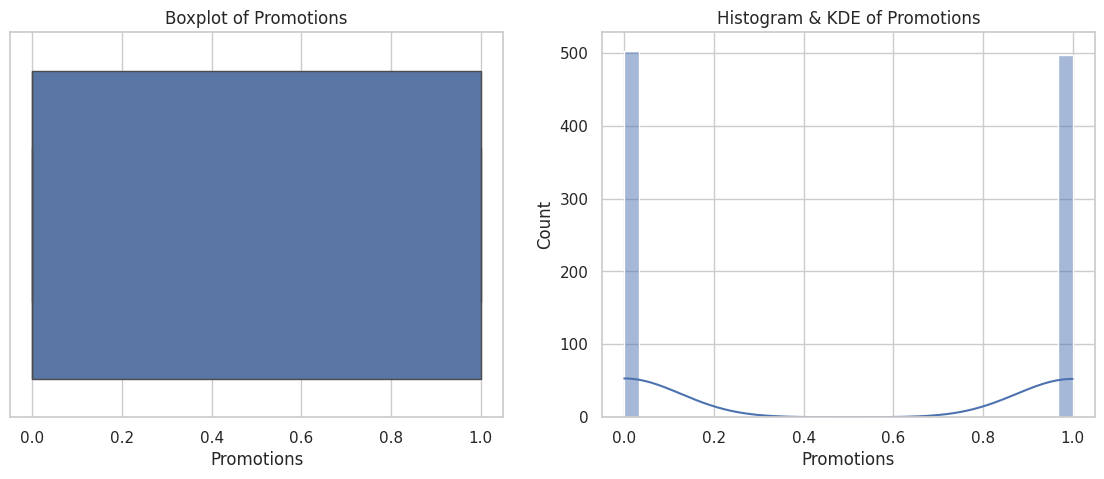

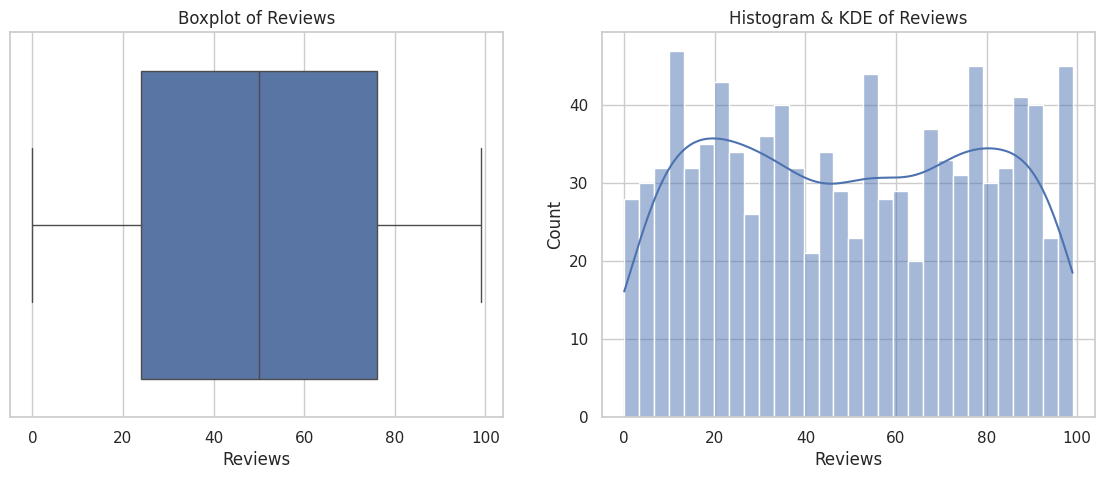

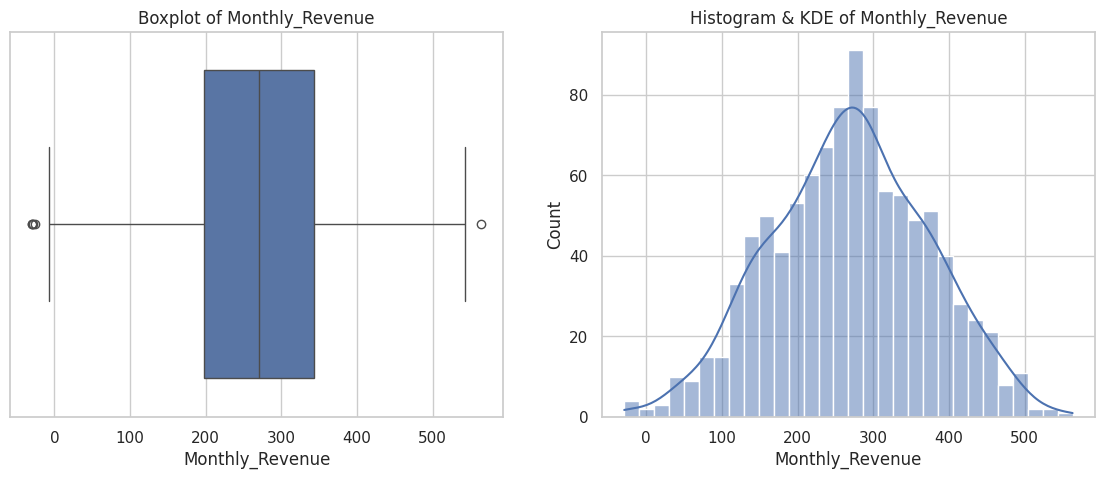

In [5]:
# Set plot style
sns.set(style="whitegrid")

# Plot boxplots and bell curves for each numerical feature
for col in numerical_data.columns:
    plt.figure(figsize=(14, 5))

    # Boxplot (shows outliers as points beyond whiskers)
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

    # Bell curve: histogram + KDE (to check distribution shape)
    plt.subplot(1, 2, 2)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Histogram & KDE of {col}')

    plt.show()

In [6]:
#performing EDA

from collections import OrderedDict
stats=[]
for i in numerical_data:
    numerical_stats=OrderedDict({
        'feature':i,
        'mean':df[i].mean(),
        'median':df[i].median(),
        'mode':df[i].mode()[0],
        'std':df[i].std(),
        'min':df[i].min(),
        'max':df[i].max(),
        'skewness':df[i].skew(),
        'kurtosis':df[i].kurt()
    })
    stats.append(numerical_stats)
    report=pd.DataFrame(stats)


# Outlier Identification :
outlier_label = []
for col in report['feature']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    LW = Q1 - 1.5 * IQR   # LW : Lower Whisker Line
    UW = Q3 + 1.5 * IQR   # UW : Upper Whisker Line
    outliers = df[(df[col] < LW) | (df[col] > UW)]
    if not outliers.empty:
        outlier_label.append("Has Outliers")
    else:
        outlier_label.append("No Outliers")

report["Outlier Comment"] = outlier_label

# Checking Report
report

,feature,mean,median,mode,std,min,max,skewness,kurtosis,Outlier Comment
0,Number_of_Customers,53.271000,54.000000,71.000000,26.364914,10.000000,99.000000,0.044938,-1.178897,No Outliers
1,Menu_Price,30.219120,30.860614,10.009501,11.278760,10.009501,49.974140,-0.055330,-1.123786,No Outliers
2,Marketing_Spend,9.958726,10.092047,0.003768,5.845586,0.003768,19.994276,-0.026283,-1.235553,No Outliers
3,Average_Customer_Spending,29.477085,29.251365,10.037177,11.471686,10.037177,49.900725,0.025268,-1.237205,No Outliers
4,Promotions,0.497000,0.000000,0.000000,0.500241,0.000000,1.000000,0.012018,-2.003867,No Outliers
5,Reviews,49.837000,50.000000,24.000000,29.226334,0.000000,99.000000,0.018223,-1.273884,No Outliers
6,Monthly_Revenue,268.724172,270.213964,-28.977809,103.982950,-28.977809,563.381332,-0.055728,-0.281384,Has Outliers


In [7]:
Q1 = df['Monthly_Revenue'].quantile(0.25)
Q3 = df['Monthly_Revenue'].quantile(0.75)
IQR = Q3 - Q1

# Calculate bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['Monthly_Revenue'] < lower_bound) | (df['Monthly_Revenue'] > upper_bound)]

# Print outliers
outliers.count

<bound method DataFrame.count of      Number_of_Customers  Menu_Price  Marketing_Spend Cuisine_Type  \
54                    11   32.620334         5.061169     American   
84                    96   16.620820        16.610689     Japanese   
104                   10   11.313867         2.279133      Italian   
110                   17   22.458927         0.874713     American   
605                   13   36.130521         0.811175      Mexican   

     Average_Customer_Spending  Promotions  Reviews  Monthly_Revenue  
54                   33.761979           1       87       -28.977809  
84                   12.284687           0       23       563.381332  
104                  16.075447           1       24       -27.610276  
110                  35.280768           1       57       -25.453430  
605                  43.119059           1       12       -28.920890  >

In [8]:
#the data is non-normally distributed
logging.info("The data is non-normally distributed")

In [9]:
df.isnull().sum()

,0
Number_of_Customers,0
Menu_Price,0
Marketing_Spend,0
Cuisine_Type,0
Average_Customer_Spending,0
Promotions,0
Reviews,0
Monthly_Revenue,0


In [10]:
#encoding cuisine type
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Cuisine_Type']=le.fit_transform(df['Cuisine_Type'])
df.head()

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
0,61,43.117635,12.663793,2,36.236133,0,45,350.912040
1,24,40.020077,4.577892,1,17.952562,0,36,221.319091
2,81,41.981485,4.652911,2,22.600420,1,91,326.529763
3,70,43.005307,4.416053,1,18.984098,1,59,348.190573
4,30,17.456199,3.475052,1,12.766143,1,30,185.009121


In [11]:
df

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
0,61,43.117635,12.663793,2,36.236133,0,45,350.912040
1,24,40.020077,4.577892,1,17.952562,0,36,221.319091
2,81,41.981485,4.652911,2,22.600420,1,91,326.529763
3,70,43.005307,4.416053,1,18.984098,1,59,348.190573
4,30,17.456199,3.475052,1,12.766143,1,30,185.009121
...,...,...,...,...,...,...,...,...
995,73,41.307842,12.122931,2,19.033585,1,40,249.312034
996,31,20.615496,5.822885,3,17.040990,0,57,110.228767
997,69,17.110656,4.141898,2,44.649315,0,55,312.212552
998,73,37.664722,3.046556,2,27.767358,0,23,272.482204


In [12]:
#dividing the dataset to prevent data leakage
X=df.drop('Monthly_Revenue',axis=1)
y=df['Monthly_Revenue']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

#the dataset has minor outliers
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train

array([[0.23595506, 0.52760437, 0.0227277 , ..., 0.61109433, 0.        ,
        0.80808081],
       [0.48314607, 0.36344531, 0.6445804 , ..., 0.70762155, 0.        ,
        0.70707071],
       [0.62921348, 0.84832925, 0.22474059, ..., 0.87888427, 1.        ,
        0.07070707],
       ...,
       [0.98876404, 0.14972415, 0.169516  , ..., 0.83905859, 0.        ,
        0.35353535],
       [0.64044944, 0.4720292 , 0.16580137, ..., 0.0702761 , 0.        ,
        0.16161616],
       [0.68539326, 0.12285201, 0.85025058, ..., 0.82301373, 0.        ,
        0.83838384]])

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Build the neural network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression (linear activation by default)
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Set early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Predict on test data
y_pred_nn = model.predict(X_test).flatten()

# Evaluate the model
r2_nn = r2_score(y_test, y_pred_nn)
mae_nn = mean_absolute_error(y_test, y_pred_nn)
mse_nn = mean_squared_error(y_test, y_pred_nn)

model.summary()

print(f"\n📊 Neural Network Performance:")
print(f"R² Score     : {r2_nn:.4f}")
print(f"MAE          : {mae_nn:.4f}")
print(f"MSE          : {mse_nn:.4f}")
print(f"RMSE         : {mse_nn ** 0.5:.4f}")


Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 79146.6484 - mae: 262.9981 - val_loss: 86269.1875 - val_mae: 273.1530
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 81772.9453 - mae: 267.6443 - val_loss: 85682.3594 - val_mae: 272.1002
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 83389.4141 - mae: 270.9580 - val_loss: 84674.8516 - val_mae: 270.2899
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 79373.7344 - mae: 263.1378 - val_loss: 82970.7188 - val_mae: 267.2046
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 74366.0156 - mae: 252.5357 - val_loss: 80207.6562 - val_mae: 262.1281
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 78728.8203 - mae: 261.6139 - val_loss: 75985.2734 - val_mae: 254.1811
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 71345.9375 - mae: 248.3916 - val_loss: 70069.3750 - val_mae: 242.6956
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 65580.4609 - mae: 235.5874 - val_los

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,877 (30.77 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,252 (20.52 KB)


📊 Neural Network Performance:
R² Score     : 0.6859
MAE          : 47.1101
MSE          : 3532.6190
RMSE         : 59.4358
